In [ ]:

from google.colab import files
uploaded = files.upload()

Saving crop_loan_dataset_realistic.xlsx to crop_loan_dataset_realistic.xlsx



--- Cross-validated Model Evaluation ---
Cross-validation Accuracy Scores: [0.78  0.725 0.785 0.795 0.735]
Mean CV Accuracy: 0.7640
Standard Deviation of CV Accuracy: 0.0284
Cross-validation Precision Scores: [0.78092775 0.72202751 0.79487218 0.79383064 0.73269305]
Mean CV Precision: 0.7649
Standard Deviation of CV Precision: 0.0312

Cross-validated Confusion Matrix:
 [[288 123]
 [113 476]]


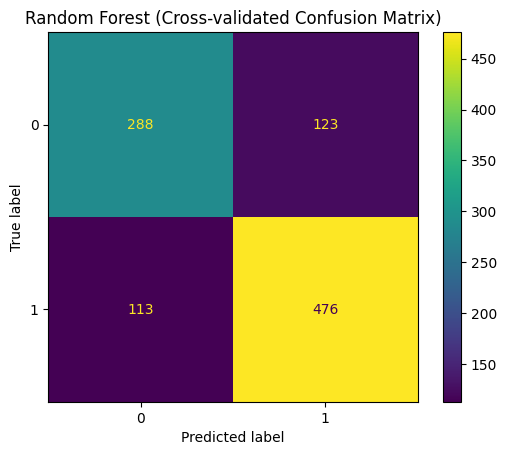

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score


df = pd.read_excel("crop_loan_dataset_realistic.xlsx")

df.head()


# ============================================================
# Step 3: Data Preprocessing
# ============================================================

df = df.drop(columns=["Application_ID"])

le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])


# ============================================================
# Step 4: Split Data (for training the initial model)
# ============================================================

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# ============================================================
# Step 5: Train Random Forest Model
# ============================================================

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


# ============================================================
# Step 6 & 7: Cross-validated Evaluation
# ============================================================

print("\n--- Cross-validated Model Evaluation ---")

# Define the number of splits for cross-validation
n_splits = 5

# Create a StratifiedKFold object
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Perform cross-validation for accuracy
cv_accuracy_scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
print(f"Cross-validation Accuracy Scores: {cv_accuracy_scores}")
print(f"Mean CV Accuracy: {cv_accuracy_scores.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_accuracy_scores.std():.4f}")

# Perform cross-validation for precision (using weighted average for imbalanced classes)
cv_precision_scores = cross_val_score(model, X, y, cv=skf, scoring='precision_weighted')
print(f"Cross-validation Precision Scores: {cv_precision_scores}")
print(f"Mean CV Precision: {cv_precision_scores.mean():.4f}")
print(f"Standard Deviation of CV Precision: {cv_precision_scores.std():.4f}")

# Get cross-validated predictions for confusion matrix (predicts for each sample when it's in the test set)
y_pred_cv = cross_val_predict(model, X, y, cv=skf)

# Compute and display the cross-validated confusion matrix
cm_cv = confusion_matrix(y, y_pred_cv)
print("\nCross-validated Confusion Matrix:\n", cm_cv)

ConfusionMatrixDisplay.from_predictions(y, y_pred_cv)
plt.title("Random Forest (Cross-validated Confusion Matrix)")
plt.show()

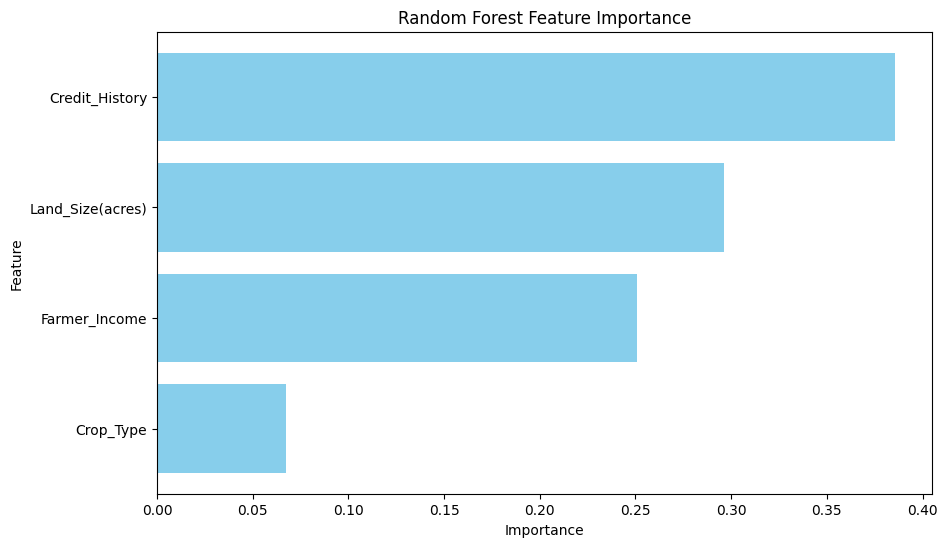

In [ ]:
# ============================================================
# Feature Importance Plot
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from the model
feature_importances = model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(features_df['Feature'], features_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature at the top
plt.show()